In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [6]:
df=pd.read_csv("hotel_bookings.csv")

In [7]:
print("shape:", df.shape)
print("\ncolumn: ")
print(df.columns)

shape: (119390, 32)

column: 
Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')


In [9]:
print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  children  babies  \
0                        0                     0       2       0.0       0   
1       

In [10]:
print(df.dtypes)

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [8]:
df.isnull()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
119386,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
119387,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
119388,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


<Axes: >

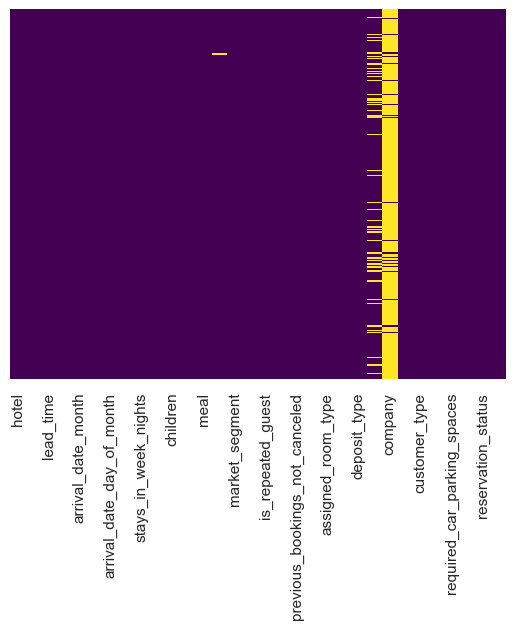

In [7]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [11]:
print('\nchecking missing values')
print(df.isnull().sum())


checking missing values
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                           

In [12]:
print("check duplicates")
print(df.duplicated().sum())

check duplicates
31994


In [14]:
print("\nstatistics:")
print(df.describe(include="all").T)


statistics:
                                   count unique         top    freq  \
hotel                             119390      2  City Hotel   79330   
is_canceled                     119390.0    NaN         NaN     NaN   
lead_time                       119390.0    NaN         NaN     NaN   
arrival_date_year               119390.0    NaN         NaN     NaN   
arrival_date_month                119390     12      August   13877   
arrival_date_week_number        119390.0    NaN         NaN     NaN   
arrival_date_day_of_month       119390.0    NaN         NaN     NaN   
stays_in_weekend_nights         119390.0    NaN         NaN     NaN   
stays_in_week_nights            119390.0    NaN         NaN     NaN   
adults                          119390.0    NaN         NaN     NaN   
children                        119386.0    NaN         NaN     NaN   
babies                          119390.0    NaN         NaN     NaN   
meal                              119390      5          BB   92

In [15]:
print("row", df.shape[0])
print("column", df.shape[1])

row 119390
column 32


In [23]:
missing=(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))
missing["missing_pct"]=missing["missing_count"]/len(df)*100
duplicated_rows=df.duplicated().sum()
display(missing[missing["missing_count"]>0])
print(duplicated_rows)

,missing_count,missing_pct
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


31994


In [33]:
df["children"]=df["children"].fillna(0)
df["country"]=df["country"].fillna("unknown")
df["agent"]=df["agent"].fillna(0)
df["company"]=df["company"].fillna(0)
df=df[(df["adults"]+df["children"]+df["babies"])>0].copy()
print("shape after cleaning", df.shape)
print("remaining missing values", df.isna().sum().sum())

shape after cleaning (119210, 32)
remaining missing values 0


In [ ]:
month_order={
     "January": 1, "February": 2, "March": 3, "April": 4,
        "May": 5, "June": 6, "July": 7, "August": 8,
        "September": 9, "October": 10, "November": 11, "December": 12
}
